In [ ]:
What is AdaBoost?

AdaBoost (Adaptive Boosting) improves performance by combining multiple weak classifiers, 
usually shallow decision trees (stumps), in a sequential manner.

Each model:
    Tries to correct the errors made by the previous one.
    Assigns higher weights to previously misclassified samples


Base Estimator: Typically a decision tree with max_depth=1.
Weights: Data points misclassified in earlier rounds get more focus.
Learning Rate: Shrinks the contribution of each classifier to prevent overfitting.
Sequential Training: Each learner is trained on a reweighted version of the dataset.

Manual AdaBoost Accuracy: 1.0


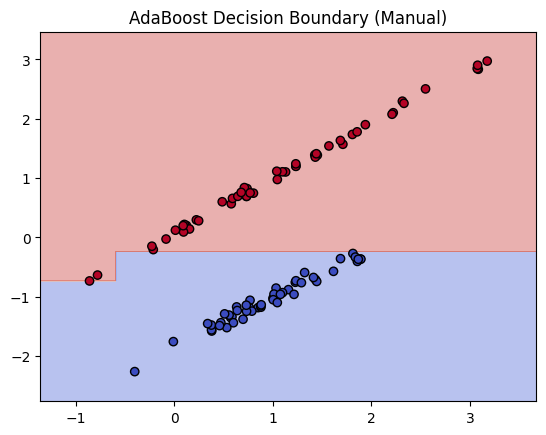

In [30]:
# manual 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create a simple binary classification dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)
# Convert labels to {-1, 1}
y = np.where(y == 0, -1, 1)

# AdaBoost an attempt to implement from scratch
class AdaBoostManual:
    def __init__(self, n_estimators=10):
        self.n_estimators = n_estimators
        self.alphas = []
        self.models = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            stump = DecisionTreeClassifier(max_depth=1)
            stump.fit(X, y, sample_weight=weights)
            preds = stump.predict(X)

            # Compute error and model weight (alpha)
            err = np.sum(weights * (preds != y)) / np.sum(weights)
            alpha = 0.5 * np.log((1 - err) / (err + 1e-10))

            # Update weights
            weights *= np.exp(-alpha * y * preds)
            weights /= np.sum(weights)  # Normalize

            # Save
            self.models.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):
        final_pred = np.zeros(X.shape[0])
        for alpha, model in zip(self.alphas, self.models):
            final_pred += alpha * model.predict(X)
        return np.sign(final_pred)

# Train and evaluate
model = AdaBoostManual(n_estimators=10)
model.fit(X, y)
y_pred = model.predict(X)

print("Manual AdaBoost Accuracy:", accuracy_score(y, y_pred))

# 4. Decision boundary visualization
def plot_decision_boundary(pred_func, X, y):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = .01  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title("AdaBoost Decision Boundary (Manual)")
    plt.show()

plot_decision_boundary(model.predict, X, y)


In [31]:
# just checking it against inbuilt function

from sklearn.ensemble import AdaBoostClassifier

clf = AdaBoostClassifier(n_estimators=10)
clf.fit(X, y)
print("Sklearn AdaBoost Accuracy:", accuracy_score(y, clf.predict(X)))


Sklearn AdaBoost Accuracy: 1.0


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Define AdaBoost with shallow trees
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the model
adaboost.fit(X_train, y_train)

# Evaluate
print(f"Train Accuracy: {adaboost.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {adaboost.score(X_test, y_test):.4f}")


Train Accuracy: 1.0000
Test Accuracy:  0.9766


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [5]:
cv_scores = cross_val_score(adaboost, X, y, cv=10)
print(f"CV Mean Accuracy: {cv_scores.mean():.4f}")
print(f"CV Variance:      {cv_scores.var():.6f}")

/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S

CV Mean Accuracy: 0.9613
CV Variance:      0.000791


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


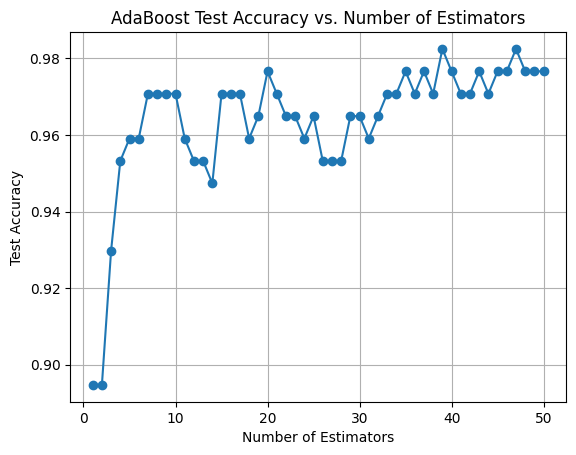

In [6]:
import matplotlib.pyplot as plt

staged_scores = list(adaboost.staged_score(X_test, y_test))
plt.plot(range(1, len(staged_scores)+1), staged_scores, marker='o')
plt.title("AdaBoost Test Accuracy vs. Number of Estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()


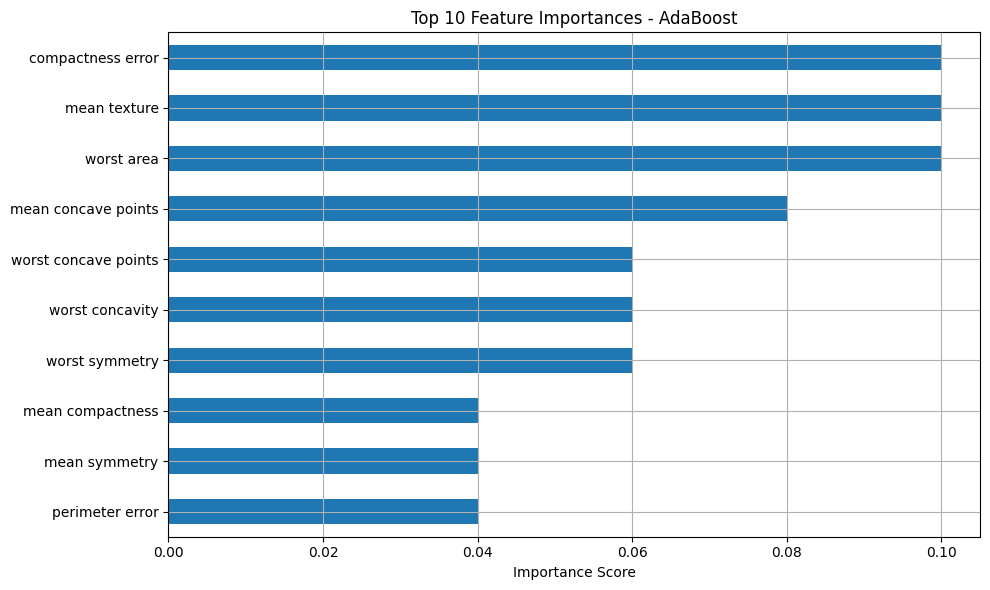

In [9]:
# Feature importance through adaboost

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from AdaBoost
importances = adaboost.feature_importances_
feature_names = load_breast_cancer().feature_names

# Plot top features
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp[:10].plot(kind='barh')
plt.title("Top 10 Feature Importances - AdaBoost")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


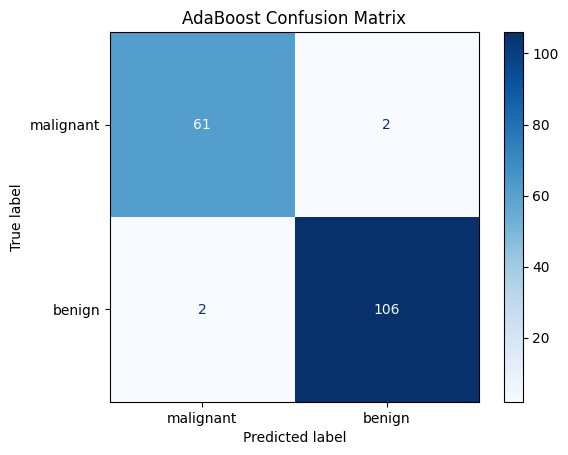

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = adaboost.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot(cmap='Blues')
plt.title("AdaBoost Confusion Matrix")
plt.grid(False)
plt.show()


# comparsion against decision trees


In [12]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Base Decision Tree (depth=1)
tree_clf = DecisionTreeClassifier(max_depth=1, random_state=42)
tree_clf.fit(X_train, y_train)

# AdaBoost with shallow trees
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada_clf.fit(X_train, y_train)

# Accuracy
print("Decision Tree:")
print(f"  Train Accuracy: {tree_clf.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:  {tree_clf.score(X_test, y_test):.4f}")

print("\nAdaBoost:")
print(f"  Train Accuracy: {ada_clf.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:  {ada_clf.score(X_test, y_test):.4f}")


Decision Tree:
  Train Accuracy: 0.9246
  Test Accuracy:  0.8947

AdaBoost:
  Train Accuracy: 1.0000
  Test Accuracy:  0.9766


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [13]:
tree_cv = cross_val_score(tree_clf, X, y, cv=10)
ada_cv = cross_val_score(ada_clf, X, y, cv=10)

print("\nCross-Validation Comparison:")
print(f"  Tree Mean Acc: {tree_cv.mean():.4f}, Variance: {tree_cv.var():.6f}")
print(f"  Ada  Mean Acc: {ada_cv.mean():.4f}, Variance: {ada_cv.var():.6f}")


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S


Cross-Validation Comparison:
  Tree Mean Acc: 0.8929, Variance: 0.000941
  Ada  Mean Acc: 0.9613, Variance: 0.000791


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


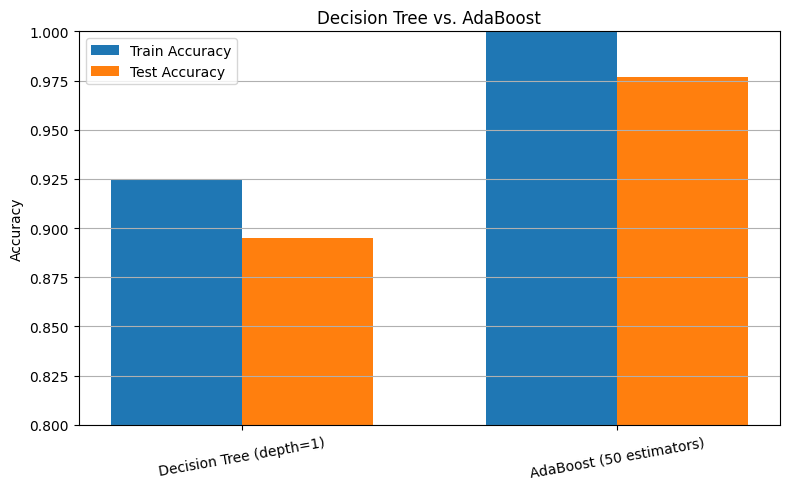

In [14]:
import matplotlib.pyplot as plt

models = ['Decision Tree (depth=1)', 'AdaBoost (50 estimators)']
train_scores = [tree_clf.score(X_train, y_train), ada_clf.score(X_train, y_train)]
test_scores  = [tree_clf.score(X_test, y_test), ada_clf.score(X_test, y_test)]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, train_scores, width, label='Train Accuracy')
ax.bar(x + width/2, test_scores, width, label='Test Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree vs. AdaBoost')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10)
ax.legend()
plt.ylim(0.8, 1.0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


# Gradient Boosting

In [ ]:
Gradient Boosting is an ensemble method that builds models sequentially, like AdaBoost, 
but instead of adjusting weights on samples, it fits new models to the residual errors (gradients) of previous models.

It’s a powerful way to minimize any differentiable loss function by using gradient descent in function space.

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Fit model
gb_clf.fit(X_train, y_train)

# Evaluate
print(f"Train Accuracy: {gb_clf.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {gb_clf.score(X_test, y_test):.4f}")


Train Accuracy: 1.0000
Test Accuracy:  0.9591


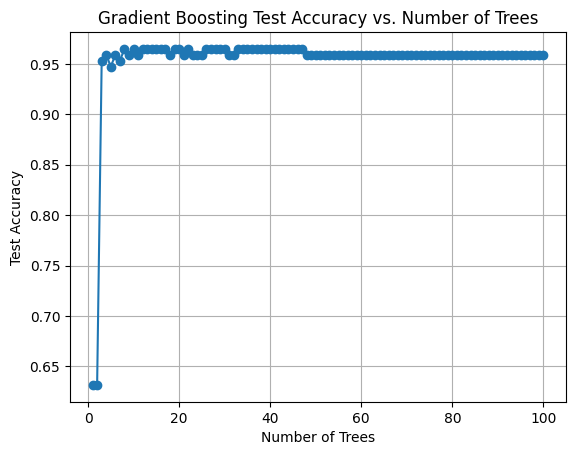

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Get staged predictions
staged_preds = gb_clf.staged_predict(X_test)

# Calculate accuracy at each stage
staged_scores = [accuracy_score(y_test, y_pred) for y_pred in staged_preds]

plt.plot(range(1, len(staged_scores) + 1), staged_scores, marker='o')
plt.title("Gradient Boosting Test Accuracy vs. Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()



In [29]:
# Adaboost vs Gradient  boosting

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# AdaBoost with shallow trees (default is DecisionTree(max_depth=1))
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Gradient Boosting
gradboost = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Cross-validation
ab_scores = cross_val_score(adaboost, X, y, cv=10)
gb_scores = cross_val_score(gradboost, X, y, cv=10)

# Show results
print("Model              Mean Accuracy   Variance")
print(f"AdaBoost           {ab_scores.mean():.4f}         {ab_scores.var():.6f}")
print(f"Gradient Boosting  {gb_scores.mean():.4f}         {gb_scores.var():.6f}")

/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S

Model              Mean Accuracy   Variance
AdaBoost           0.9613         0.000791
Gradient Boosting  0.9614         0.000849


In [ ]:
# whole comparsion

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
import numpy as np

# Load data
data = load_breast_cancer()
X, y = data.data, data.target

# Models
dtree = DecisionTreeClassifier(max_depth=None, random_state=42)
rforest = RandomForestClassifier(n_estimators=100, random_state=42)
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

models = {'Decision Tree': dtree, 'Random Forest': rforest, 'AdaBoost': ada}

print("10-Fold Cross-Validation Results:\n")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10)
    print(f"{name}:")
    print(f"  Mean Accuracy = {scores.mean():.4f}")
    print(f"  Variance of Accuracy = {scores.var():.6f}")
    print(f"  Std Dev of Accuracy = {scores.std():.4f}\n")


10-Fold Cross-Validation Results:

Decision Tree:
  Mean Accuracy = 0.9280
  Variance of Accuracy = 0.001071
  Std Dev of Accuracy = 0.0327

Random Forest:
  Mean Accuracy = 0.9632
  Variance of Accuracy = 0.000951
  Std Dev of Accuracy = 0.0308



/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S

AdaBoost:
  Mean Accuracy = 0.9683
  Variance of Accuracy = 0.000546
  Std Dev of Accuracy = 0.0234



# bar chart to show redunction in variance

/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S

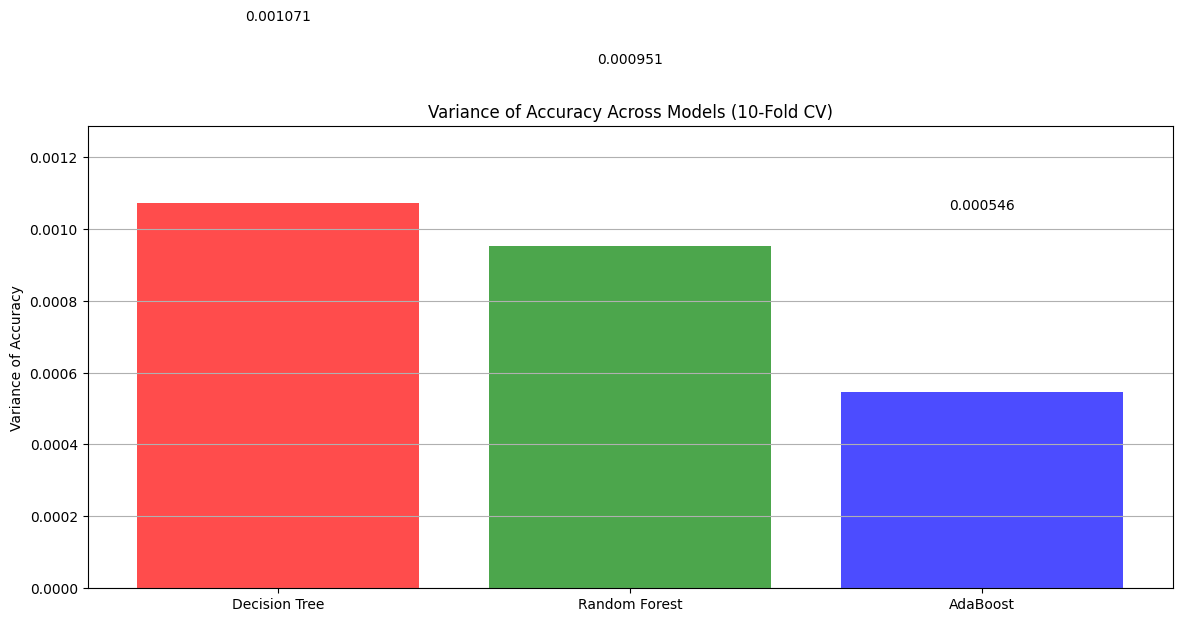

In [25]:
import matplotlib.pyplot as plt

# Cross-validation scores already calculated in previous code
models = ['Decision Tree', 'Random Forest', 'AdaBoost']
variances = []
means = []
std_devs = []

for name, model in zip(models, [dtree, rforest, ada]):
    scores = cross_val_score(model, X, y, cv=10)
    variances.append(scores.var())
    means.append(scores.mean())
    std_devs.append(scores.std())

# Plot
plt.figure(figsize=(14,6))
bars = plt.bar(models, variances, color=['red', 'green', 'blue'], alpha=0.7)

plt.title('Variance of Accuracy Across Models (10-Fold CV)')
plt.ylabel('Variance of Accuracy')
plt.ylim(0, max(variances)*1.2)

# Add variance numbers on top of bars
for bar, var in zip(bars, variances):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0005, f"{var:.6f}", ha='center', va='bottom')

plt.grid(axis='y')
plt.show()


In [27]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import zero_one_loss

def bias_variance_decomp(model, X_train, y_train, X_test, y_test, n_rounds=50):
    preds = np.zeros((n_rounds, len(y_test)))

    for i in range(n_rounds):
        # Bootstrap sample of train set
        X_resampled, y_resampled = resample(X_train, y_train, random_state=i)
        model.fit(X_resampled, y_resampled)
        preds[i] = model.predict(X_test)

    avg_preds = np.round(preds.mean(axis=0))  # majority vote approx.
    
    # Bias = zero_one_loss between avg prediction and true label
    bias = zero_one_loss(y_test, avg_preds)
    
    # Variance = average variance of predictions per sample
    variance = np.mean(np.var(preds, axis=0))
    
    # Total error approx = bias + variance + irreducible error (unknown)
    total_error = zero_one_loss(y_test, preds.mean(axis=0).round())
    
    return bias, variance, total_error

# Split data once
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    bias, var, err = bias_variance_decomp(model, X_train, y_train, X_test, y_test)
    results[name] = {'bias': bias, 'variance': var, 'total_error': err}

print("Bias and Variance estimates:\n")
for name, vals in results.items():
    print(f"{name}: Bias={vals['bias']:.4f}, Variance={vals['variance']:.4f}, Total Error={vals['total_error']:.4f}")


/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/home/monsley/anaconda3/envs/E3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the S

Bias and Variance estimates:

Decision Tree: Bias=0.0409, Variance=0.0392, Total Error=0.0409
Random Forest: Bias=0.0351, Variance=0.0089, Total Error=0.0351
AdaBoost: Bias=0.0292, Variance=0.0164, Total Error=0.0292


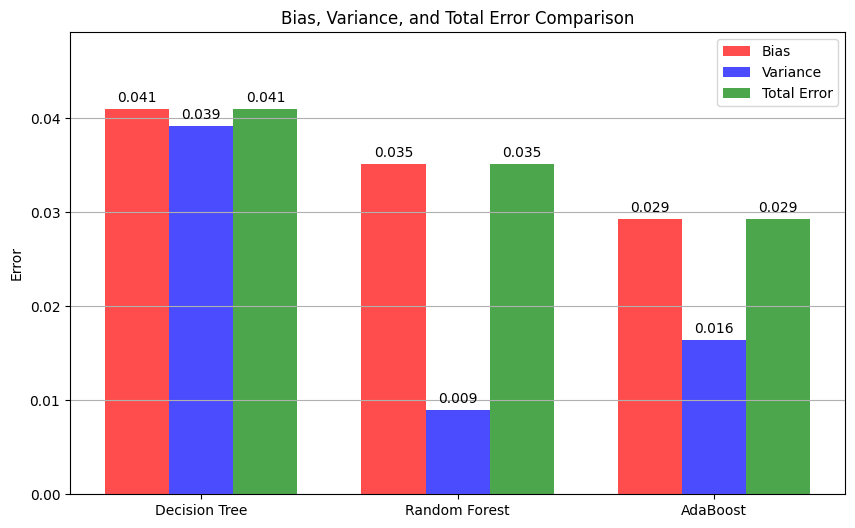

In [28]:
models = list(results.keys())
bias = [results[m]['bias'] for m in models]
variance = [results[m]['variance'] for m in models]
total_error = [results[m]['total_error'] for m in models]

x = np.arange(len(models))  # label locations
width = 0.25  # width of bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width, bias, width, label='Bias', color='red', alpha=0.7)
rects2 = ax.bar(x, variance, width, label='Variance', color='blue', alpha=0.7)
rects3 = ax.bar(x + width, total_error, width, label='Total Error', color='green', alpha=0.7)

ax.set_ylabel('Error')
ax.set_title('Bias, Variance, and Total Error Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.ylim(0, max(total_error) * 1.2)
plt.grid(axis='y')
plt.show()